# Explanory analysis 
This notebook  is developed to explore summary data from the Climate Reporting Entity (CRE) Search Hub. 
* `pdfs_2024` The first analysis was conducted in June 2024 for 35 companies (including 30 companies reported as of 7 May 2024 and 5 extra banks from 2022-2023) 
* `pdfs_2026` The second analysis was conducted in May 2026 for 198 companies (across all target years in 2023-2026)

In [1]:
import ast, re, time, os, requests
import pandas as pd
import numpy as np
from datetime import date
import seaborn as sns 
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import textwrap

# ── Publication style ──────────────────────────────────────────────────────────
rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})


def make_autopct(values):
    def autopct(pct):
        count = int(round(pct * sum(values) / 100))
        return f'{count}\n({pct:.1f}%)'
    return autopct

#!pip install matplotlib_venn

In [2]:
# Output folder for CSVs and PDFs — update if running on a different machine
FOLDER     = r'C:\Users\QuyenN\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\3-Webscrapping & PDF disclosure'
FIG_FOLDER =  r'C:\Users\QuyenN\OneDrive - ESNZ\Offline_work\2_GNS\19_LLM_ClimateRisk2026\5-Analysis2026'  
PDF_FOLDER_2026 = os.path.join(FOLDER, 'pdfs_2026')
PDF_FOLDER_2024 = os.path.join(FOLDER, 'pdfs_2024')

In [3]:
#Get the list of disclosures download in 2024
disclosure_2024 = pd.read_excel(os.path.join(PDF_FOLDER_2024, "List of firms with Climate Reports-2024.xlsx"),
                              sheet_name="0.master_firm2024", parse_dates=['PeriodDate','DueDate'])
disclosure_2024['Company Name'] = disclosure_2024['Company Name'].str.replace("WESTPAC","WESTPAC BANKING CORPORATION")
#Change westpac name to be consistent with 2026 data
company_2024 = disclosure_2024["Company Name"].tolist()
print(f"Number of firms with disclosures in 2024: {len(company_2024)}")
disclosure_2024.head()

Number of firms with disclosures in 2024: 33


,Company Name,PeriodDate,DueDate,ExtraDownload
0,PROPERTY FOR INDUSTRY LIMITED,2023-12-31,2024-07-31,NaN
1,"CITIBANK, N.A.",2023-12-31,2024-07-31,NaN
2,AIA NEW ZEALAND LIMITED,2023-12-31,2024-07-31,NaN
3,ANZ NEW ZEALAND INVESTMENTS LIMITED,2024-03-31,2024-07-31,yes
4,ASB BANK LIMITED,2024-06-30,2024-07-31,yes


In [4]:
#Get the list of companies and disclosures downloaded in 2026
disclose_2026 = pd.read_csv(os.path.join(FOLDER, 'pdfs_2026', 'List_of_all_disclosures_as_of_2026.csv'))
print(f"Number of disclosures in 2026: {len(disclose_2026)}")
company_2026 = disclose_2026['Company Name'].drop_duplicates().tolist()
print(f"Number of firms with disclosures in 2026: {len(company_2026)}")
company_2026
#Compare the two lists to find new firms that disclosed in 2026 but not in 2024
new_firms_2026 = set(company_2026) - set(company_2024)
#Compare the list of firms in 2024 that did not disclose in 2026
missing_firms_2026 = set(company_2024) - set(company_2026)
print(f"Number of firms with disclosures in 2024 but not in 2026: {len(missing_firms_2026)}")
print(f"Number of new firms with disclosures in 2026 (not in 2024): {len(new_firms_2026)}")


Number of disclosures in 2026: 743
Number of firms with disclosures in 2026: 173
Number of firms with disclosures in 2024 but not in 2026: 0
Number of new firms with disclosures in 2026 (not in 2024): 140


### Now start analyse the composite of 2026 companies

In [5]:
industry = pd.read_excel(os.path.join(FIG_FOLDER,'Explatorary_Analysis_2026.xlsx'),sheet_name='MasterIndustry')
industry.head()

,Company Name,Industry,Types
0,AA INSURANCE LIMITED,Finance - Insurance,Normal companies
1,AFT PHARMACEUTICALS LIMITED,Pharmaceuticals,Normal companies
2,AIA NEW ZEALAND LIMITED,Finance - Insurance,Normal companies
3,AIG INSURANCE NEW ZEALAND LIMITED,Finance - Insurance,Normal companies
4,AIR NEW ZEALAND LIMITED,Airport,Normal companies


In [172]:
#Read the 2026 disclosure data again for further analysis
disclose_2026 = pd.read_csv(os.path.join(FOLDER, 'pdfs_2026', 'List_of_all_disclosures_as_of_2026.csv'))
#Get master industry
industry = pd.read_excel(os.path.join(FIG_FOLDER,'Explatorary_Analysis_2026.xlsx'),sheet_name='MasterIndustry')
#Combine company name and scheme for easy calculation, if not investment scheme, use company name only
disclose_2026["Company_Scheme"] = (
    disclose_2026["Company Name"]
    + disclose_2026["Investment Scheme Name"].apply(lambda x: f"|{x}" if pd.notna(x) else "")
)
#Drop link for easy calculation
disclose_2026 = disclose_2026.drop(columns=["Link", "DocumentLink","PeriodHref"])
#Get the unique company name and investment scheme name
print(f"Number of unique company and investment scheme combinations: {len(disclose_2026['Company_Scheme'].drop_duplicates())}")
#Get period date
disclose_2026['PeriodDate'] = pd.to_datetime(
    disclose_2026['PeriodText'].str.extract(r'(\d{2}[/\-]\d{2}[/\-]\d{4})')[0],
    dayfirst=True,
    errors='coerce'
)

#Merge between 2024 and 2026 disclosure data to get the period date for 2024 disclosures
disclosure_2024['Analysed_2024'] =1 #Flag for 2024 disclosure data
disclose_2026 = disclose_2026.merge(disclosure_2024[['Company Name','PeriodDate',"Analysed_2024"]],
                                  left_on=['Company Name','PeriodDate'],
                                  right_on=['Company Name','PeriodDate'],
                                  how='left')
# Map Type
disclose_2026['Type'] = disclose_2026['Type'].map({
    'companies': 'Normal companies',
    'investment schemes': 'Investment schemes'}).fillna('Other')

# Classify status based on PeriodText
def classify_status(text):
    t = str(text).lower()
    if re.search(r'(select to view|click to view)', t):
        return 'Submitted'
    elif 'not required to lodge' in t:
        return 'Not required to lodge'
    elif 'due by' in t:
        return 'Not yet submitted'
    else:
        return 'Unknown'
disclose_2026['Status'] = disclose_2026['PeriodText'].apply(classify_status)

# Classify period day based on the time stamps 
bins   = [pd.Timestamp.min,
          pd.Timestamp('2024-06-30'),
          pd.Timestamp('2025-06-30'),
          pd.Timestamp('2026-06-30')]

labels = ['Cohort 1 (≤ Jun 2024)',
          'Cohort 2 (Jul 2024 – Jun 2025)',
          'Cohort 3 (Jul 2025 – Jun 2026)']

disclose_2026['Cohort'] = pd.cut(
    disclose_2026['PeriodDate'],
    bins=bins,
    labels=labels,
    right=True
)

disclose_2026['Cohort'].value_counts().sort_index()

### Now crawling all the files that have been downloaded and give me the number of files PDf for each of them
def get_pdf_info(company, period_year,PDF_FOLDER):
    safe_name = re.sub(r'[^\w\s-]', '', company)[:50].strip().replace(' ', '_') + f"_{period_year}"
    company_folder = os.path.join(PDF_FOLDER, safe_name)
    pdfs = glob.glob(os.path.join(company_folder, '*.pdf'))
    filenames = [os.path.basename(p) for p in pdfs]
    return filenames, len(filenames)

PDF_FOLDER = os.path.join(FOLDER, 'pdfs_2026','pdfs')

disclose_2026[['pdf_files', 'pdf_count']] = disclose_2026.apply(
    lambda r: pd.Series(get_pdf_info(r['Company Name'], r['period_year'],PDF_FOLDER)),
    axis=1
)
disclose_2026['no_pdf'] = np.where(disclose_2026['pdf_count'] == 0, 1, 0)
# Quick summary
print(f"Number of firms without PDF is {disclose_2026[disclose_2026['pdf_count']==0].shape[0]} out of {disclose_2026.shape[0]}")
# Update with industry
disclose_2026 = disclose_2026.merge(industry,how = 'left',
                                    left_on = 'Company Name',
                                    right_on = 'Company Name')

# Breakdown by status 
disclose_2026.to_csv( os.path.join(FIG_FOLDER,"List_of_all_disclosures_as_of_2026_mapped.csv"))
disclose_2026.head()

Number of unique company and investment scheme combinations: 274
Number of firms without PDF is 178 out of 743


,Company Name,PeriodText,Type,Investment Scheme Name,status,period_year,Company_Scheme,PeriodDate,Analysed_2024,Status,Cohort,pdf_files,pdf_count,no_pdf,Industry,Types
0,AA INSURANCE LIMITED,30-06-2025 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2025,AA INSURANCE LIMITED,2025-06-30,NaN,Submitted,Cohort 2 (Jul 2024 – Jun 2025),[AA Insurance 2025 Climate Statement FINAL SIG...,2,0,Finance - Insurance,Normal companies
1,AA INSURANCE LIMITED,30-06-2024 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2024,AA INSURANCE LIMITED,2024-06-30,NaN,Submitted,Cohort 1 (≤ Jun 2024),[AA Insurance 2024 Climate Statements.pdf],1,0,Finance - Insurance,Normal companies
2,AFT PHARMACEUTICALS LIMITED,31-03-2024 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2024,AFT PHARMACEUTICALS LIMITED,2024-03-31,NaN,Submitted,Cohort 1 (≤ Jun 2024),"[240523 FY2024 Annual Report.pdf, FY2024 Annua...",2,0,Pharmaceuticals,Normal companies
3,AFT PHARMACEUTICALS LIMITED,31-03-2025 - Select to view climate statement ...,Normal companies,NaN,Have records and have submitted,2025,AFT PHARMACEUTICALS LIMITED,2025-03-31,NaN,Submitted,Cohort 2 (Jul 2024 – Jun 2025),[250522 AFT FY25 Annual Report.pdf],1,0,Pharmaceuticals,Normal companies
4,AFT PHARMACEUTICALS LIMITED,31-03-2026 - Due by 31-07-2026,Normal companies,NaN,Have records but not submitted,2026,AFT PHARMACEUTICALS LIMITED,2026-03-31,NaN,Not yet submitted,Cohort 3 (Jul 2025 – Jun 2026),[],0,1,Pharmaceuticals,Normal companies


### Now check those without pdf 

In [164]:
no_pdf = disclose_2026.groupby(['Cohort','Status'])['no_pdf'].agg(
    count='count',
    no_pdf_count='sum',
    no_pdf_pct=lambda x: round(x.mean() * 100, 1)
)
no_pdf.to_csv(os.path.join(FIG_FOLDER,"Table00_Number_of_disclosures_without_pdf.csv"))
no_pdf

C:\Users\Quyen\AppData\Local\Temp\ipykernel_26180\2022775349.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  no_pdf = disclose_2026.groupby(['Cohort','Status'])['no_pdf'].agg(


count  no_pdf_count  \
Cohort                         Status                                       
Cohort 1 (≤ Jun 2024)          Not required to lodge      9             3   
                               Not yet submitted          0             0   
                               Submitted                245             2   
Cohort 2 (Jul 2024 – Jun 2025) Not required to lodge     22             4   
                               Not yet submitted          1             1   
                               Submitted                266             6   
Cohort 3 (Jul 2025 – Jun 2026) Not required to lodge      2             2   
                               Not yet submitted        159           157   
                               Submitted                 39             3   

                                                      no_pdf_pct  
Cohort                         Status                             
Cohort 1 (≤ Jun 2024)          Not required to lodge        33.3  
                               Not yet submitted             NaN  
                               Submitted                     0.8  
Cohort 2 (Jul 2024 – Jun 2025) Not required to lodge        18.2  
                               Not yet submitted           100.0  
                               Submitted                     2.3  
Cohort 3 (Jul 2025 – Jun 2026) Not required to lodge       100.0  
                               Not yet submitted            98.7  
                               Submitted                     7.7

### Now draw the pie chart with the number of firms 

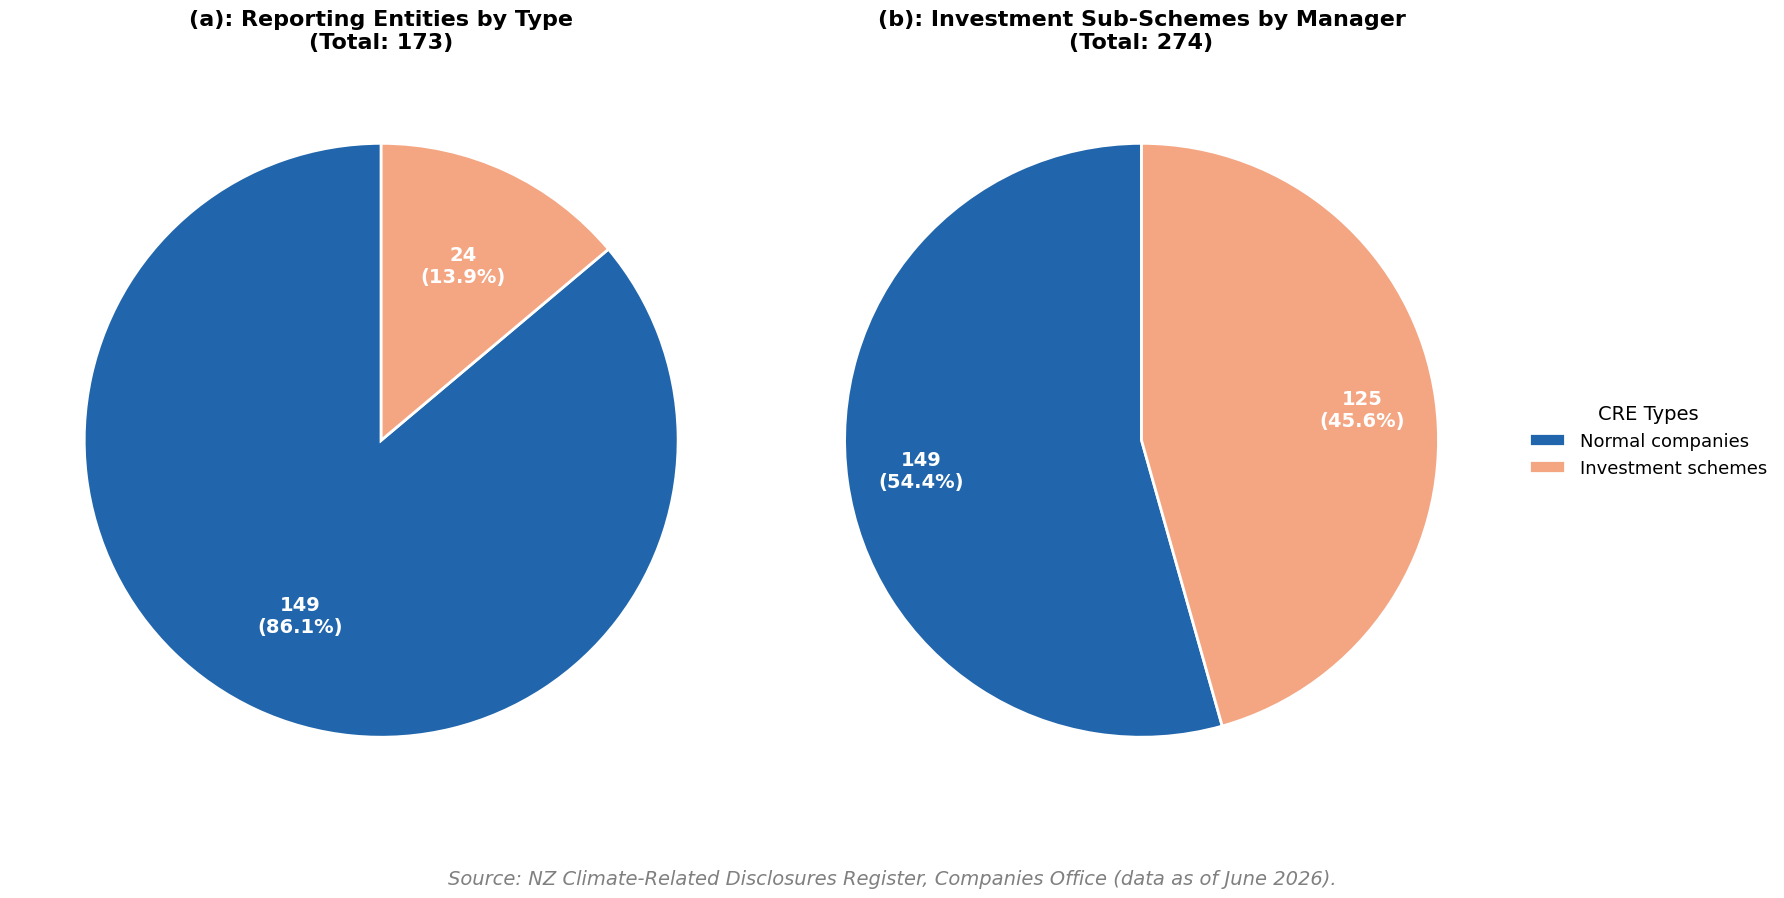

In [158]:
#Now draw two pie chart, the first pie chart is the list of unique firms in 2026 disclosure data (normal firm and schemes), 
# the second pie chart is the list of sub schemes from the scheme. 
# The two pie charts should be side by side for easy comparison.
# Clean qualitative — colorblind-safe
COLORS = [ '#2166AC', '#F4A582', '#A6DBA0']

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('white')
# ── Pie 1 ──────────────────────────────────────────────────────────────────────
unique_firms = disclose_2026.drop_duplicates(subset='Company Name')
type_counts  = unique_firms['Type'].value_counts()

wedges1, texts1, autotexts1 = axes[0].pie(
    type_counts,
    labels=None,
    autopct=make_autopct(type_counts),
    startangle=90,
    colors=COLORS,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.65,
    textprops=dict(fontsize=14, fontweight='bold'),
)
for at in autotexts1:
    at.set_color('white')


axes[0].set_title(f'(a): Reporting Entities by Type\n(Total: {len(unique_firms)})',
                  pad=15, fontsize=16)

# ── Pie 2 ──────────────────────────────────────────────────────────────────────
scheme_firms  =disclose_2026.drop_duplicates(subset='Company_Scheme')
scheme_counts = scheme_firms['Type'].value_counts()

threshold   = 2
other_count = scheme_counts[scheme_counts <= threshold].sum()
scheme_counts = scheme_counts[scheme_counts > threshold]
if other_count > 0:
    scheme_counts['Other'] = other_count

wedges2, texts2, autotexts2 = axes[1].pie(
    scheme_counts,
    labels=None,
    autopct=make_autopct(scheme_counts),
    startangle=90,
    colors=COLORS,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.75,
    textprops=dict(fontsize=14, fontweight='bold'),
)
for at in autotexts2:
    at.set_color('white')

axes[1].legend(
    wedges2, scheme_counts.index,
    title='CRE Types', title_fontsize=14,
    loc='center left', bbox_to_anchor=(1.0, 0.5),
    frameon=False, fontsize=13,
)
axes[1].set_title(f'(b): Investment Sub-Schemes by Manager\n(Total: {len(scheme_firms)})',
                  pad=15, fontsize=16)

# ── Caption ────────────────────────────────────────────────────────────────────
fig.text(0.5, -0.01,
         'Source: NZ Climate-Related Disclosures Register, Companies Office (data as of June 2026).',
         ha='center', fontsize=14, color='grey', style='italic')

plt.tight_layout()
plt.savefig(os.path.join(FIG_FOLDER,  'Fig01_disclosure_pie_charts.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



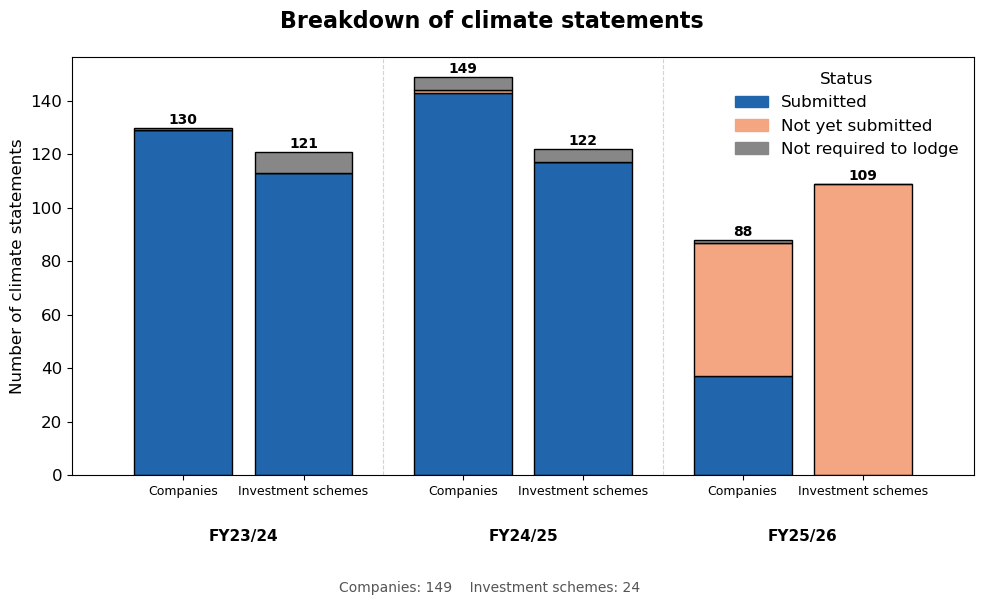

In [23]:
### Now, breakdown by the cohort and status — single plot, N vs I clustered by cohort
import matplotlib.pyplot as plt
import numpy as np

disclose_2026 = pd.read_csv( os.path.join(FIG_FOLDER,"List_of_all_disclosures_as_of_2026_mapped.csv"))

unique_2026 = disclose_2026.drop_duplicates(subset=['Company_Scheme', 'PeriodDate'])

STATUS_COLORS = {
    'Submitted':             '#2166AC',
    'Not yet submitted':     '#F4A582',
    'Not required to lodge': '#878787',
    'Unknown':               '#D1D1D1',
}

normal = unique_2026[unique_2026['Type'] != 'Investment schemes']
invest = unique_2026[unique_2026['Type'] == 'Investment schemes']

def make_pivot(df):
    return df.pivot_table(index='Cohort', columns='Status', values='Company_Scheme',
                          aggfunc='count', observed=True)

pt_normal = make_pivot(normal)
pt_invest = make_pivot(invest)

# Align rows and columns across both pivots
all_statuses = [s for s in STATUS_COLORS if s in pt_normal.columns or s in pt_invest.columns]
all_cohorts  = sorted(set(pt_normal.index) | set(pt_invest.index))
pt_normal = pt_normal.reindex(index=all_cohorts, columns=all_statuses)
pt_invest = pt_invest.reindex(index=all_cohorts, columns=all_statuses)

n     = len(all_cohorts)
bar_w = 0.35
pad   = 0.08

group_centers = np.arange(n, dtype=float)
x_n = group_centers - bar_w / 2 - pad / 2
x_i = group_centers + bar_w / 2 + pad / 2

fig, ax = plt.subplots(figsize=(10, 6))

bottom_n = np.zeros(n)
bottom_i = np.zeros(n)

for status in all_statuses:
    vals_n = pt_normal[status].fillna(0).values
    vals_i = pt_invest[status].fillna(0).values
    ax.bar(x_n, vals_n, bar_w, bottom=bottom_n, color=STATUS_COLORS[status], edgecolor = 'black')
    ax.bar(x_i, vals_i, bar_w, bottom=bottom_i, color=STATUS_COLORS[status], edgecolor = 'black')
    bottom_n += vals_n
    bottom_i += vals_i

# Totals on top of each stacked bar
for i in range(n):
    if bottom_n[i] > 0:
        ax.text(x_n[i], bottom_n[i] + 0.4, str(int(bottom_n[i])),
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    if bottom_i[i] > 0:
        ax.text(x_i[i], bottom_i[i] + 0.4, str(int(bottom_i[i])),
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# X-axis: N / I sub-labels at each bar, cohort label at group center below
all_bar_x, all_bar_lbl = [], []
for i in range(n):
    all_bar_x.extend([x_n[i], x_i[i]])
    all_bar_lbl.extend(['Companies', 'Investment schemes'])
ax.set_xticks(all_bar_x)
ax.set_xticklabels(all_bar_lbl, fontsize=9)

trans = ax.get_xaxis_transform()
for i, cohort in enumerate(all_cohorts):
    ax.text(group_centers[i], -0.13, str(cohort), ha='center', va='top',
            fontsize=11, fontweight='bold', transform=trans)

# Dashed separator between cohort groups
for i in range(n - 1):
    ax.axvline((group_centers[i] + group_centers[i + 1]) / 2,
               color='lightgrey', linestyle='--', linewidth=0.8)

ax.set_ylabel('Number of climate statements')
ax.set_xlabel('')
ax.margins(x=0.08)
ax.set_ylim(bottom=0)

# Status legend (top-right)
status_handles = [plt.Rectangle((0, 0), 1, 1, color=STATUS_COLORS[s]) for s in all_statuses]
ax.legend(status_handles, all_statuses, title='Status', loc='upper right', frameon=False)

# Type annotation below chart
unique_firms = disclose_2026.drop_duplicates(subset='Company Name')
type_counts  = unique_firms['Type'].value_counts()
n_companies = type_counts['Normal companies']
n_schemes = type_counts['Investment schemes']

fig.text(0.5, 0.01, f'Companies: {n_companies}    Investment schemes: {n_schemes} ',
         ha='center', fontsize=10, color='#555')

fig.suptitle('Breakdown of climate statements', fontweight='bold', fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(os.path.join(FIG_FOLDER, 'Fig03_disclosure_overtime_bystatus_uniqueCREs.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
